# Classificação do Dataset Iris com Redes Neurais

Este notebook demonstra a construção de uma rede neural artificial para classificar flores do dataset Iris utilizando **TensorFlow/Keras**.

O dataset Iris é um dos mais famosos em machine learning, contendo 150 amostras de flores com 4 características cada:
- Comprimento da sépala
- Largura da sépala
- Comprimento da pétala
- Largura da pétala

As flores são classificadas em 3 espécies: **Setosa**, **Versicolor** e **Virginica**.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
import keras
from keras import layers
from keras.utils import to_categorical

## 1. Importação das Bibliotecas

Importamos as bibliotecas necessárias:
- **NumPy/Matplotlib**: manipulação de arrays e visualização
- **scikit-learn**: carregamento de dados, pré-processamento e métricas
- **TensorFlow/Keras**: construção e treinamento da rede neural

In [3]:
iris = load_iris()
X = iris.data                # (150, 4)
d = iris.target              # (150,) com classes 0,1,2
class_names = iris.target_names

print("X:", X.shape, "d:", d.shape, "classes:", np.unique(d))

X: (150, 4) d: (150,) classes: [0 1 2]


## 2. Carregamento do Dataset

Carregamos o dataset Iris do scikit-learn:
- `X`: matriz de características (150 amostras × 4 features)
- `d`: vetor de rótulos (classes 0, 1 e 2)

In [4]:
print("X (amostra):\n", X[:5])
print("d (completo):\n", d)

X (amostra):
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
d (completo):
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [5]:
# treino+val vs teste
X_trainval, X_test, d_trainval, d_test = train_test_split(
    X, d, test_size=0.20, random_state=42, stratify=d
)

# treino vs validação
X_train, X_val, d_train, d_val = train_test_split(
    X_trainval, d_trainval, test_size=0.16, random_state=42, stratify=d_trainval
)

# normalização (fit só no treino)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# one-hot (para saída softmax + categorical_crossentropy)
d_train_oh = to_categorical(d_train, num_classes=3)
d_val_oh   = to_categorical(d_val,   num_classes=3)
d_test_oh  = to_categorical(d_test,  num_classes=3)

print("Treino:", X_train.shape, d_train_oh.shape)
print("Val:   ", X_val.shape,   d_val_oh.shape)
print("Teste: ", X_test.shape,  d_test_oh.shape)

Treino: (100, 4) (100, 3)
Val:    (20, 4) (20, 3)
Teste:  (30, 4) (30, 3)


## 3. Pré-processamento dos Dados

Etapas de preparação dos dados:

1. **Divisão dos dados**: separamos em treino (100), validação (20) e teste (30)
2. **Normalização**: aplicamos `StandardScaler` para padronizar as features (média=0, desvio=1)
3. **One-Hot Encoding**: convertemos os rótulos para formato categórico (ex: classe 1 → [0, 1, 0])

> ⚠️ O `fit` do scaler é feito **apenas no treino** para evitar vazamento de dados (data leakage).

In [6]:
print("X:\n", X_train[:5])
print("d:\n", d_train_oh[:5])

X:
 [[-1.11801229  1.22494019 -1.3248626  -1.44387786]
 [ 0.19589104 -0.74371369  0.78170879  0.55226665]
 [ 1.50979438 -0.08749573  1.23718368  1.21764815]
 [ 0.55422832 -1.18119233  0.72477443  0.95149555]
 [-0.04300047 -0.96245301  0.15543081  0.01996145]]
d:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]


In [8]:
tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(8, activation="tanh"),     # você pode variar 3, 10, 50 depois
    layers.Dense(3, activation="softmax")
])
    # Opções de funções de ativação
      # activation='relu'  # Função mais comum, usada em camadas ocultas
      # activation='sigmoid'  # Para saída binária (0 ou 1)
      # activation='softmax'  # Para classificação multiclasse
      # activation='tanh'  # Alternativa ao ReLU, pode ser útil para dados normalizados
      # activation='linear'  # Retorna a entrada sem modificar, útil em regressões

model.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",         # cross-entropy multiclasse (one-hot)
    metrics=["accuracy"]
)
  ## Alternativas dos parâmetros acima:
  #1 Opções de otimizadores
      # optimizer='sgd'  # Stochastic Gradient Descent (descida do gradiente estocástica)
      # optimizer='adam'  # Adaptive Moment Estimation (Adam)
      # optimizer='adagrad'  # Adaptive Gradient, ajusta taxa de aprendizado automaticamente
      # optimizer='nadam'  # Nesterov-accelerated Adaptive Moment Estimation, variação do Adam
  #2 Opções de funções de perda (loss)
      # loss='categorical_crossentropy'  # Para classificação multiclasse com one-hot encoding
      # loss='sparse_categorical_crossentropy'  # Para classificação multiclasse com labels inteiros
      # loss='binary_crossentropy'  # Para classificação binária (0 ou 1)
      # loss='mean_squared_error'  # Erro quadrático médio, usado em regressão
      # loss='mean_absolute_error'  # Erro absoluto médio, penaliza menos que MSE
      # loss='huber'  # Combinação de MSE e MAE, útil para lidar com outliers
  #3 Opções de métricas de avaliação (colocar quantas quiser)
      # metrics=['accuracy']  # Para classificação com classes balanceadas
      # metrics=['precision', 'recall']  # Para problemas desbalanceados
      # metrics=['mse']  # Mean Squared Error, usado para regressão
      # metrics=['mae']  # Mean Absolute Error, usado para regressão

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Construção do Modelo

Criamos uma rede neural **Multilayer Perceptron (MLP)** com a API Sequential do Keras:

| Camada | Neurônios | Ativação | Descrição |
|--------|-----------|----------|-----------|
| Input | 4 | - | Entrada com 4 características |
| Dense | 8 | tanh | Camada oculta |
| Dense | 3 | softmax | Camada de saída (probabilidades) |

**Compilação:**
- **Otimizador**: SGD (Stochastic Gradient Descent)
- **Loss**: Categorical Crossentropy (para classificação multiclasse)
- **Métrica**: Accuracy

In [9]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
# Opções de monitoramento para EarlyStopping
    # monitor='val_loss'  # Perda no conjunto de validação (mais comum)
    # monitor='loss'  # Perda no conjunto de treino
    # monitor='val_accuracy'  # Acurácia no conjunto de validação
    # monitor='accuracy'  # Acurácia no conjunto de treino
history = model.fit(
    X_train, d_train_oh,
    validation_data=(X_val, d_val_oh),
    epochs=300,
    batch_size=15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2800 - loss: 1.1576 - val_accuracy: 0.3500 - val_loss: 1.0639
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3100 - loss: 1.0817 - val_accuracy: 0.3500 - val_loss: 1.0013
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3300 - loss: 1.0149 - val_accuracy: 0.3500 - val_loss: 0.9464
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3400 - loss: 0.9560 - val_accuracy: 0.3500 - val_loss: 0.8982
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3700 - loss: 0.9040 - val_accuracy: 0.4000 - val_loss: 0.8558
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4600 - loss: 0.8580 - val_accuracy: 0.5000 - val_loss: 0.8184
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5400 - loss: 0.8172 - val_accuracy: 0.6500 - val_loss: 0.7852
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6300 - loss: 0.7809 - val_accuracy: 0.6500 - val_loss: 0.7558

## 5. Treinamento do Modelo

Treinamos a rede neural com os seguintes parâmetros:
- **Épocas**: até 300 (com early stopping)
- **Batch size**: 15 amostras por iteração
- **Early Stopping**: interrompe o treino se a `val_loss` não melhorar por 5 épocas consecutivas

O callback `EarlyStopping` restaura automaticamente os pesos da melhor época, evitando overfitting.

In [10]:
test_loss, test_acc = model.evaluate(X_test, d_test_oh, verbose=0)
print("Loss teste:", test_loss)
print("Accuracy teste:", test_acc)

Loss teste: 0.181099072098732
Accuracy teste: 0.9333333373069763


## 6. Avaliação no Conjunto de Teste

Avaliamos o modelo no conjunto de teste (dados nunca vistos durante o treino) para medir a generalização.

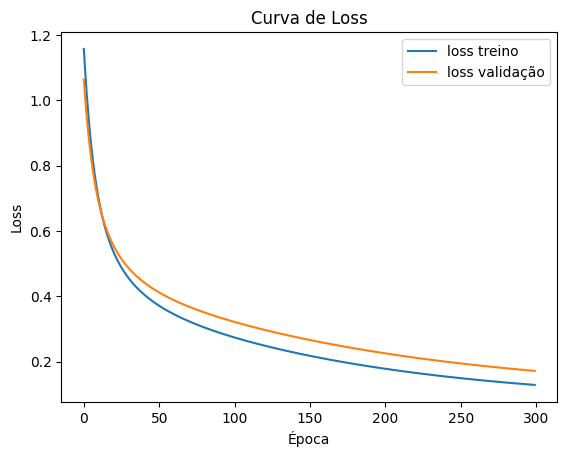

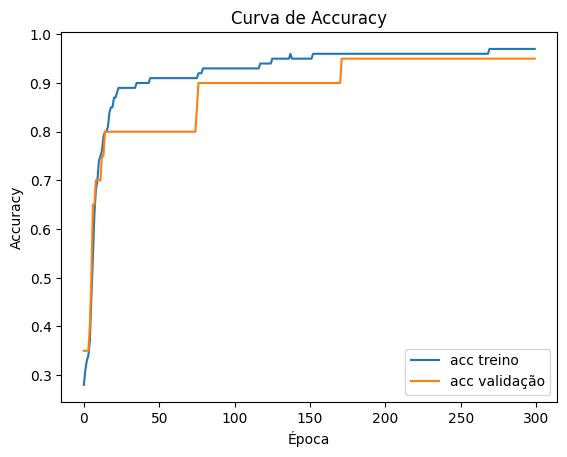

In [11]:
plt.plot(history.history["loss"], label="loss treino")
plt.plot(history.history["val_loss"], label="loss validação")
plt.legend()
plt.title("Curva de Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.plot(history.history["accuracy"], label="acc treino")
plt.plot(history.history["val_accuracy"], label="acc validação")
plt.legend()
plt.title("Curva de Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.show()

## 7. Visualização das Curvas de Aprendizado

Os gráficos mostram a evolução do **loss** e **accuracy** ao longo das épocas:
- Se as curvas de treino e validação divergem muito → **overfitting**
- Se ambas permanecem altas → **underfitting**
- Idealmente, ambas devem convergir para valores baixos (loss) ou altos (accuracy)

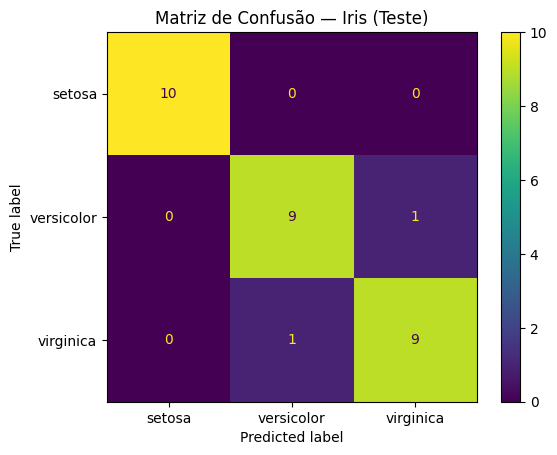

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [12]:
probs = model.predict(X_test, verbose=0)
y = np.argmax(probs, axis=1)

cm = confusion_matrix(d_test, y)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.title("Matriz de Confusão — Iris (Teste)")
plt.show()

print(classification_report(d_test, y, target_names=class_names))

## 8. Matriz de Confusão e Relatório de Classificação

A **matriz de confusão** mostra os acertos e erros por classe:
- Diagonal principal: classificações corretas
- Fora da diagonal: erros (confusões entre classes)

O **classification report** apresenta métricas detalhadas:
- **Precision**: dos que o modelo disse ser X, quantos realmente são X?
- **Recall**: dos que realmente são X, quantos o modelo acertou?
- **F1-Score**: média harmônica entre precision e recall

In [13]:
for i in range(min(10, len(X_test))):
    print(
        f"Real: {class_names[d_test[i]]:10s} | Prev: {class_names[y[i]]:10s} | probs={np.round(probs[i], 3)}"
    )

Real: setosa     | Prev: setosa     | probs=[0.976 0.024 0.   ]
Real: virginica  | Prev: virginica  | probs=[0.003 0.201 0.796]
Real: versicolor | Prev: versicolor | probs=[0.097 0.896 0.007]
Real: versicolor | Prev: versicolor | probs=[0.06  0.931 0.008]
Real: setosa     | Prev: setosa     | probs=[0.981 0.019 0.   ]
Real: versicolor | Prev: versicolor | probs=[0.029 0.502 0.469]
Real: setosa     | Prev: setosa     | probs=[0.986 0.014 0.   ]
Real: setosa     | Prev: setosa     | probs=[0.975 0.025 0.   ]
Real: virginica  | Prev: virginica  | probs=[0.001 0.081 0.918]
Real: versicolor | Prev: versicolor | probs=[0.044 0.606 0.35 ]


## 9. Análise de Predições Individuais

Visualizamos algumas predições com suas probabilidades. A rede neural retorna um vetor de probabilidades para cada classe, e a classe com maior probabilidade é a predição final.

In [14]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd

---

## 10. Busca de Hiperparâmetros (Grid Search)

Utilizamos **GridSearchCV** do scikit-learn para encontrar a melhor combinação de hiperparâmetros da rede neural. O **SciKeras** permite integrar modelos Keras com a API do scikit-learn.

In [16]:
def criar_rede_finetuning(optimizer="sgd",
                          kernel_initializer="glorot_uniform",
                          activation="tanh",
                          neurons=8):

    tf.keras.backend.clear_session()

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4,)),
        tf.keras.layers.Dense(
            units=neurons,
            activation=activation,
            kernel_initializer=kernel_initializer
        ),
        tf.keras.layers.Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### Função para Criar o Modelo

Definimos uma função que cria a rede neural com parâmetros configuráveis. Isso permite que o GridSearch teste diferentes combinações.

In [17]:
classificador = KerasClassifier(
    model=criar_rede_finetuning
)

In [18]:
parametros = {
    "batch_size": [4, 8, 16],
    "epochs": [4, 8, 16],
    "model__optimizer": ["sgd"],
    "model__kernel_initializer": ["random_uniform"],
    "model__activation": ["tanh"],
    "model__neurons": [4, 8, 16, 32]
}

### Grade de Hiperparâmetros

Definimos os valores a serem testados:
- **batch_size**: quantidade de amostras por atualização dos pesos
- **epochs**: número de passadas completas pelo dataset
- **neurons**: quantidade de neurônios na camada oculta

In [19]:
grid_search = GridSearchCV(
    estimator=classificador,
    param_grid=parametros,
    cv=3,
    scoring="accuracy"
)

grid_search.fit(X_train, d_train_oh)


Epoch 1/4
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6970 - loss: 1.0251  
Epoch 2/4
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8030 - loss: 0.8819 
Epoch 3/4
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8182 - loss: 0.7919 
Epoch 4/4
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8182 - loss: 0.7308 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Epoch 1/4
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7761 - loss: 0.9781  
Epoch 2/4
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8806 - loss: 0.8200 
Epoch 3/4
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8806 - loss: 0.7305 
Epoch 4/4
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8806 - loss: 0.6722 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Epoch 1/4
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3134 - loss: 1.0638      
Epoch 2/4
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5821 - loss: 0.9528 
Epoch 3/4
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7015 - loss: 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'batch_size': [4, 8, ...], 'epochs': [4, 8, ...], 'model__activation': ['tanh'], 'model__kernel_initializer': ['random_uniform'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

### Execução do Grid Search

O GridSearchCV treina o modelo com todas as combinações de parâmetros usando validação cruzada (3-fold). Isso avalia cada configuração de forma mais robusta.

In [20]:
import pandas as pd

resultados = pd.DataFrame(grid_search.cv_results_)

tabela_resultados = resultados[[
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'param_batch_size',
    'param_epochs',
    'param_model__optimizer',
    'param_model__kernel_initializer',
    'param_model__activation',
    'param_model__neurons'
]].copy()

tabela_resultados.columns = [
    'ranking',
    'acuracia',
    'd_padrao',
    'batch',
    'epochs',
    'optimizer',
    'kernel_initializer',
    'activation',
    'neurons'
]

tabela_resultados = tabela_resultados.sort_values(by='ranking')

print(tabela_resultados)

# Melhor Resultado
melhores_parametros = grid_search.best_params_
melhor_precisao = grid_search.best_score_

print("Melhores parâmetros encontrados:", melhores_parametros)
print("Melhor precisão obtida:", melhor_precisao)

    ranking  acuracia  d_padrao  batch  epochs optimizer kernel_initializer  \
11        1  0.889483  0.038590      4      16       sgd     random_uniform   
10        2  0.869281  0.052321      4      16       sgd     random_uniform   
9         3  0.829471  0.039386      4      16       sgd     random_uniform   
7         4  0.828877  0.080366      4       8       sgd     random_uniform   
29        5  0.808675  0.100776     16       8       sgd     random_uniform   
22        6  0.799762  0.029910      8      16       sgd     random_uniform   
35        6  0.799762  0.029910     16      16       sgd     random_uniform   
3         8  0.799168  0.063813      4       4       sgd     random_uniform   
0         9  0.798871  0.080781      4       4       sgd     random_uniform   
15       10  0.798574  0.112323      8       4       sgd     random_uniform   
5        10  0.798574  0.112323      4       8       sgd     random_uniform   
1        10  0.798574  0.100835      4       4      

### Resultados do Grid Search

Exibimos os resultados ordenados por ranking, mostrando a acurácia média e os parâmetros testados. Os melhores hiperparâmetros encontrados podem ser usados para treinar o modelo final.